# Entrega 3 — Modelo final, interpretación y comunicación

---

### Estructura del notebook

| Sección | Contenido |
|---|---|
| **1. Configuración** | Imports, semilla, estilos |
| **2. Reproducción del estado final** | Datos, splits y modelo ganador de Entrega 2 |
| **3. Evaluación final** | Métricas completas sobre test, curvas ROC y PR |
| **4. Interpretabilidad — SHAP** | Valores globales y locales, dependencias |
| **5. Análisis de sensibilidad** | Curvas de aprendizaje y robustez del modelo |
| **6. Análisis de errores profundo** | Perfiles FP/FN, segmentación de errores |
| **7. Justificación de decisiones** | Registro técnico de cada elección metodológica |
| **8. Conclusiones y recomendaciones** | Conclusiones del trabajo realizado |


---
## 1. Configuración del entorno

In [4]:
# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import shap
import warnings
warnings.filterwarnings("ignore")

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, learning_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score,
    roc_curve, precision_recall_curve,
    classification_report, ConfusionMatrixDisplay
)
from lightgbm import LGBMClassifier
# SMOTE e ImbPipeline no se usan en esta entrega:
# el ganador es LightGBM + class_weight (is_unbalance=True),
# que no requiere oversampling externo.

# ── Semilla y estilo ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
PALETTE = ["#2C6EAB", "#E84855", "#F4A261", "#2A9D8F"]

print("Entorno configurado.")
print(f"  shap       : {shap.__version__}")
import sklearn, lightgbm
print(f"  sklearn    : {sklearn.__version__}")
print(f"  lightgbm   : {lightgbm.__version__}")


Entorno configurado.
  shap       : 0.51.0
  sklearn    : 1.8.0
  lightgbm   : 4.6.0


---
## 2. Reproducción del estado final

**Decisiones que vienen de la Entrega 2:**
- `duration` excluida por *data leakage*
- Split 80/20 estratificado con `random_state=42`
- Modelo ganador: **LightGBM + class_weight** (`is_unbalance=True`) — mayor F1 en 5-fold CV estratificada (0.4535 vs 0.3822 de SMOTE)
- Umbral de decisión ajustado según curva Precision-Recall

In [6]:
# Carga de datos
df = pd.read_csv("../data/bank-full.csv", sep=";")

TARGET = "y"
LEAKAGE_COLS = ["duration"]

X = df.drop(columns=[TARGET] + LEAKAGE_COLS)
y = (df[TARGET] == "yes").astype(int)   # yes=1, no=0

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20,
    random_state=RANDOM_STATE, stratify=y
)

print("División de conjuntos")
print(f"  Train : {X_train.shape[0]:,}  |  positivos: {y_train.mean():.3f}")
print(f"  Test  : {X_test.shape[0]:,}   |  positivos: {y_test.mean():.3f}")
print(f"  Features: {X_train.shape[1]} (sin 'duration')")

División de conjuntos
  Train : 36,168  |  positivos: 0.117
  Test  : 9,043   |  positivos: 0.117
  Features: 15 (sin 'duration')


In [7]:
# Preprocesador y pipeline final

NUM_COLS = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
CAT_COLS = X_train.select_dtypes(include="object").columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), NUM_COLS),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_COLS)
])

# Pipeline final
pipeline_final = Pipeline(steps=[
    ("prep",  preprocessor),
    ("model", LGBMClassifier(
        n_estimators  = 300,
        is_unbalance  = True, 
        random_state  = RANDOM_STATE,
        n_jobs        = -1,
        verbose       = -1
    ))
])

print("Pipeline final construido (LightGBM + class_weight):")
print("1. ColumnTransformer (StandardScaler + OneHotEncoder)")
print("2. LGBMClassifier (n_estimators=300, is_unbalance=True)")

Pipeline final construido (LightGBM + class_weight):
1. ColumnTransformer (StandardScaler + OneHotEncoder)
2. LGBMClassifier (n_estimators=300, is_unbalance=True)


In [8]:
# Validación cruzada final
# Corremos 5-fold CV sobre el modelo final (LightGBM + class_weight) para confirmar que los resultados son consistentes con los de la Entrega 2.

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = {"roc_auc": "roc_auc", "f1": "f1", "accuracy": "accuracy",
           "precision": "precision", "recall": "recall"}

cv_results = cross_validate(
    pipeline_final, X_train, y_train,
    cv=CV, scoring=SCORING, n_jobs=-1
)

print("Desempeño en 5-fold CV (LightGBM + class_weight)")
for metrica in SCORING:
    vals = cv_results[f"test_{metrica}"]
    print(f"  {metrica:<12}: {vals.mean():.4f} ± {vals.std():.4f}")
print()
print("Referencia Entrega 2 — LightGBM + class_weight:")
print("  roc_auc     : 0.7831 ± 0.0048")
print("  f1          : 0.4535 ± 0.0032")
print()
print("Cada métrica es la media sobre 5 pliegues.")
print("La desviación estándar mide la estabilidad del modelo.")


Desempeño en 5-fold CV (LightGBM + class_weight)
  roc_auc     : 0.7831 ± 0.0048
  f1          : 0.4535 ± 0.0032
  accuracy    : 0.8365 ± 0.0048
  precision   : 0.3726 ± 0.0079
  recall      : 0.5798 ± 0.0138

Referencia Entrega 2 — LightGBM + class_weight:
  roc_auc     : 0.7831 ± 0.0048
  f1          : 0.4535 ± 0.0032

Cada métrica es la media sobre 5 pliegues.
La desviación estándar mide la estabilidad del modelo.


In [9]:
# Entrenamiento final y cálculo de umbral
# Paso 1: entrenar sobre X_train completo
pipeline_final.fit(X_train, y_train)

# Paso 2: calcular umbral óptimo usando el modelo ya entrenado sobre un hold-out interno de X_train
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.20,
    random_state=RANDOM_STATE, stratify=y_train
)
# Solo predict_proba, NO fit — el modelo ya está entrenado
y_proba_val = pipeline_final.predict_proba(X_val)[:, 1]

precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_val, y_proba_val)
f1_curve = np.where(
    (precision_curve[:-1] + recall_curve[:-1]) > 0,
    2 * precision_curve[:-1] * recall_curve[:-1] / (precision_curve[:-1] + recall_curve[:-1]),
    0
)
UMBRAL_OPTIMO = thresholds_pr[np.argmax(f1_curve)]

# Paso 3: calcular probabilidades sobre test
y_proba_test = pipeline_final.predict_proba(X_test)[:, 1]
y_pred_test  = (y_proba_test >= UMBRAL_OPTIMO).astype(int)

print(f"Umbral óptimo (calculado sobre hold-out de X_train): {UMBRAL_OPTIMO:.4f}")
print(f"Modelo entrenado sobre {len(X_train):,} muestras (fit único).")
print("X_test listo para evaluación final en Sección 3.")


Umbral óptimo (calculado sobre hold-out de X_train): 0.6892
Modelo entrenado sobre 36,168 muestras (fit único).
X_test listo para evaluación final en Sección 3.


---
## 3. Evaluación final sobre el conjunto de test

In [11]:
# Métricas finales sobre test
# Reportamos el conjunto completo de métricas para dar una visión integral del desempeño

metricas_test = {
    "ROC-AUC"  : roc_auc_score(y_test, y_proba_test),
    "F1-score" : f1_score(y_test, y_pred_test),
    "Recall"   : recall_score(y_test, y_pred_test),
    "Precision": precision_score(y_test, y_pred_test),
    "Accuracy" : accuracy_score(y_test, y_pred_test)
}

print("------- EVALUACIÓN FINAL — Conjunto de TEST -------")
print(f"  Modelo   : LightGBM + class_weight (is_unbalance=True)")
print(f"  Umbral   : {UMBRAL_OPTIMO:.4f}")
print(f"  Muestras : {len(y_test):,} (20% del dataset original)")
print()
for nombre, valor in metricas_test.items():
    print(f"  {nombre:<12}: {valor:.4f}")
print()
# Evaluación honesta del objetivo
auc_val = metricas_test["ROC-AUC"]
if auc_val >= 0.85:
    print(f"  ✓ ROC-AUC = {auc_val:.4f} → objetivo de investigación cumplido (≥ 0.85).")
else:
    print(f"  ✗ ROC-AUC = {auc_val:.4f} → objetivo no alcanzado (meta: ≥ 0.85).")
    print(f"    Brecha: {0.85 - auc_val:.4f} puntos.")

------- EVALUACIÓN FINAL — Conjunto de TEST -------
  Modelo   : LightGBM + class_weight (is_unbalance=True)
  Umbral   : 0.6892
  Muestras : 9,043 (20% del dataset original)

  ROC-AUC     : 0.7871
  F1-score    : 0.4787
  Recall      : 0.4509
  Precision   : 0.5102
  Accuracy    : 0.8851

  ✗ ROC-AUC = 0.7871 → objetivo no alcanzado (meta: ≥ 0.85).
    Brecha: 0.0629 puntos.


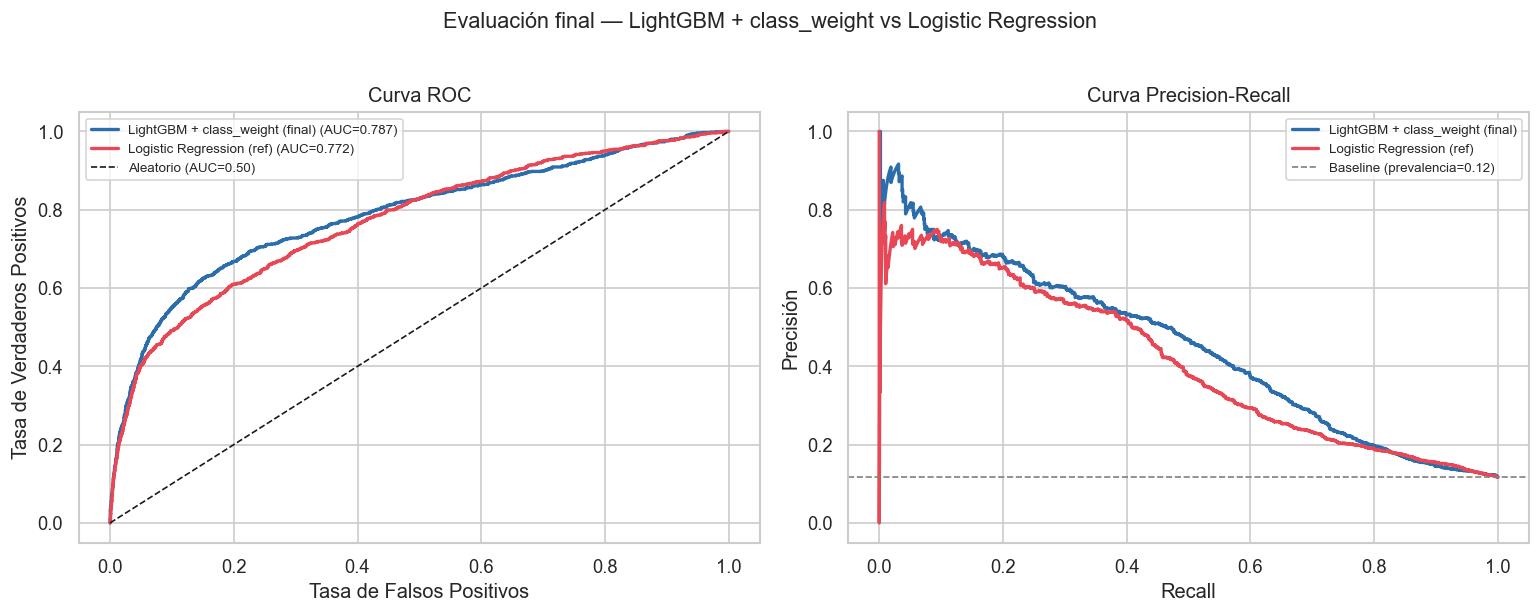

In [12]:
# Curvas ROC y Precision-Recall
# Incluimos la Regresión Logística (Entrega 2) como referencia de comparación.

# Modelo de referencia: LR sin técnica de desbalance
pipe_lr_ref = Pipeline([
    ("prep",  preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
pipe_lr_ref.fit(X_train, y_train)
y_proba_lr = pipe_lr_ref.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: Curva ROC
for proba, nombre, color in [
    (y_proba_test, "LightGBM + class_weight (final)", PALETTE[0]),
    (y_proba_lr,   "Logistic Regression (ref)", PALETTE[1])
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, linewidth=2,
                 label=f"{nombre} (AUC={auc:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="Aleatorio (AUC=0.50)")
axes[0].set_xlabel("Tasa de Falsos Positivos")
axes[0].set_ylabel("Tasa de Verdaderos Positivos")
axes[0].set_title("Curva ROC", fontsize=12)
axes[0].legend(fontsize=8)

# Panel derecho: Curva Precision-Recall
for proba, nombre, color in [
    (y_proba_test, "LightGBM + class_weight (final)", PALETTE[0]),
    (y_proba_lr,   "Logistic Regression (ref)", PALETTE[1])
]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, color=color, linewidth=2, label=nombre)

prevalencia = y_test.mean()
axes[1].axhline(prevalencia, color="gray", linestyle="--", linewidth=1,
                label=f"Baseline (prevalencia={prevalencia:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precisión")
axes[1].set_title("Curva Precision-Recall", fontsize=12)
axes[1].legend(fontsize=8)

plt.suptitle("Evaluación final — LightGBM + class_weight vs Logistic Regression",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../figures/fig_e3_01_curvas_roc_pr.png", bbox_inches="tight")
plt.show()

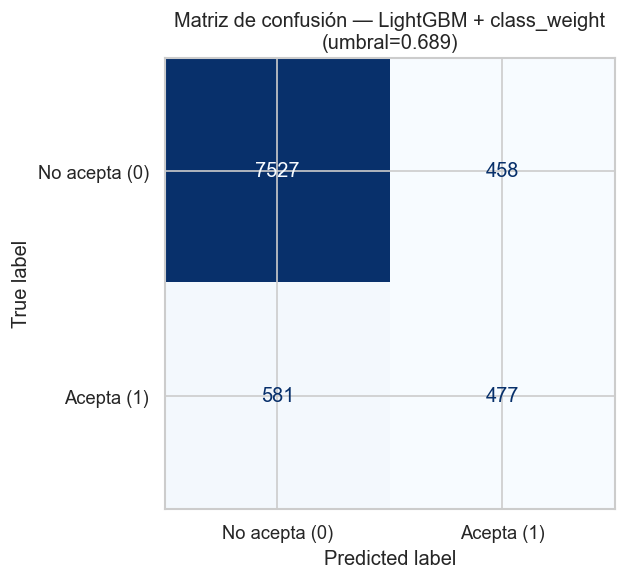

---------- Reporte de clasificación completo ------------
              precision    recall  f1-score   support

          no       0.93      0.94      0.94      7985
         yes       0.51      0.45      0.48      1058

    accuracy                           0.89      9043
   macro avg       0.72      0.70      0.71      9043
weighted avg       0.88      0.89      0.88      9043



In [13]:
# Matriz de confusión final
# La matriz de confusión desglosa los 4 tipos de predicción:
#   TN: predice no, es no (correcto)
#   FP: predice yes, es no (falso positivo — costo: llamada innecesaria)
#   FN: predice no, es yes (falso negativo — costo: oportunidad perdida)
#   TP: predice yes, es yes (correcto)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=["No acepta (0)", "Acepta (1)"],
    colorbar=False, ax=ax, cmap="Blues"
)
ax.set_title(f"Matriz de confusión — LightGBM + class_weight\n(umbral={UMBRAL_OPTIMO:.3f})",
             fontsize=12)
plt.tight_layout()
plt.savefig("../figures/fig_e3_02_confusion_matrix.png", bbox_inches="tight")
plt.show()

print("---------- Reporte de clasificación completo ------------")
print(classification_report(y_test, y_pred_test, target_names=["no", "yes"]))

In [14]:
# Tabla comparativa: modelo final vs baselines
# Contextualizamos el desempeño final contra los puntos de referencia establecidos en las entregas anteriores.

from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

tabla_comparativa = pd.DataFrame([
    {
        "Modelo"    : "DummyClassifier (Entrega 1)",
        "ROC-AUC"   : 0.50,
        "F1"        : 0.00,
        "Recall"    : 0.00,
        "Precision" : 0.00,
        "Accuracy"  : accuracy_score(y_test, y_pred_dummy)
    },
    {
        "Modelo"    : "Logistic Regression (Entrega 2)",
        "ROC-AUC"   : roc_auc_score(y_test, y_proba_lr),
        "F1"        : f1_score(y_test, pipe_lr_ref.predict(X_test)),
        "Recall"    : recall_score(y_test, pipe_lr_ref.predict(X_test)),
        "Precision" : precision_score(y_test, pipe_lr_ref.predict(X_test)),
        "Accuracy"  : accuracy_score(y_test, pipe_lr_ref.predict(X_test))
    },
    {
        "Modelo"    : "LightGBM + class_weight (FINAL)",
        "ROC-AUC"   : metricas_test["ROC-AUC"],
        "F1"        : metricas_test["F1-score"],
        "Recall"    : metricas_test["Recall"],
        "Precision" : metricas_test["Precision"],
        "Accuracy"  : metricas_test["Accuracy"]
    }
])

print("-- Progresión a lo largo de las entregas ----------------")
print(tabla_comparativa.to_string(index=False, float_format="{:.4f}".format))

-- Progresión a lo largo de las entregas ----------------
                         Modelo  ROC-AUC     F1  Recall  Precision  Accuracy
    DummyClassifier (Entrega 1)   0.5000 0.0000  0.0000     0.0000    0.8830
Logistic Regression (Entrega 2)   0.7717 0.2815  0.1786     0.6632    0.8933
LightGBM + class_weight (FINAL)   0.7871 0.4787  0.4509     0.5102    0.8851


---
## 4. Interpretabilidad — Análisis SHAP

### ¿Por qué SHAP?

SHAP (SHapley Additive exPlanations) asigna a cada variable un valor que representa **cuánto contribuyó** a que el modelo predijera lo que predijo para cada observación. A diferencia de feature_importances, SHAP:
- Muestra la dirección del efecto (si aumentar la variable sube o baja la predicción)
- Es local (explica predicciones individuales) y global (resume el comportamiento general)

In [15]:
# Preparación: transformar X_test para SHAP

# Extraemos las partes del pipeline
prep_fitted  = pipeline_final.named_steps["prep"]
lgbm_model   = pipeline_final.named_steps["model"]

# Transformamos X_test (el preprocesador ya fue ajustado sobre X_train)
X_test_prep = prep_fitted.transform(X_test)

# Nombres de columnas tras OneHotEncoder
ohe       = prep_fitted.named_transformers_["cat"]
cat_names = ohe.get_feature_names_out(CAT_COLS).tolist()
col_names = NUM_COLS + cat_names

X_test_prep_df = pd.DataFrame(X_test_prep, columns=col_names)

print(f"X_test preprocesado: {X_test_prep_df.shape}")
print(f"  Numéricas originales: {len(NUM_COLS)}")
print(f"  Tras OneHotEncoder  : {len(cat_names)} columnas adicionales")

X_test preprocesado: (9043, 50)
  Numéricas originales: 6
  Tras OneHotEncoder  : 44 columnas adicionales


In [16]:
# Cálculo de valores SHAP

explainer  = shap.TreeExplainer(lgbm_model)

# Muestra aleatoria para gráficas globales
N_SHAP = min(1000, len(X_test_prep_df))
idx_shap = np.random.choice(len(X_test_prep_df), N_SHAP, replace=False)
X_shap   = X_test_prep_df.iloc[idx_shap].reset_index(drop=True)

shap_values = explainer(X_shap)

print(f"Valores SHAP calculados sobre {N_SHAP} observaciones.")
print(f"Shape de shap_values: {shap_values.values.shape}")

Valores SHAP calculados sobre 1000 observaciones.
Shape de shap_values: (1000, 50)


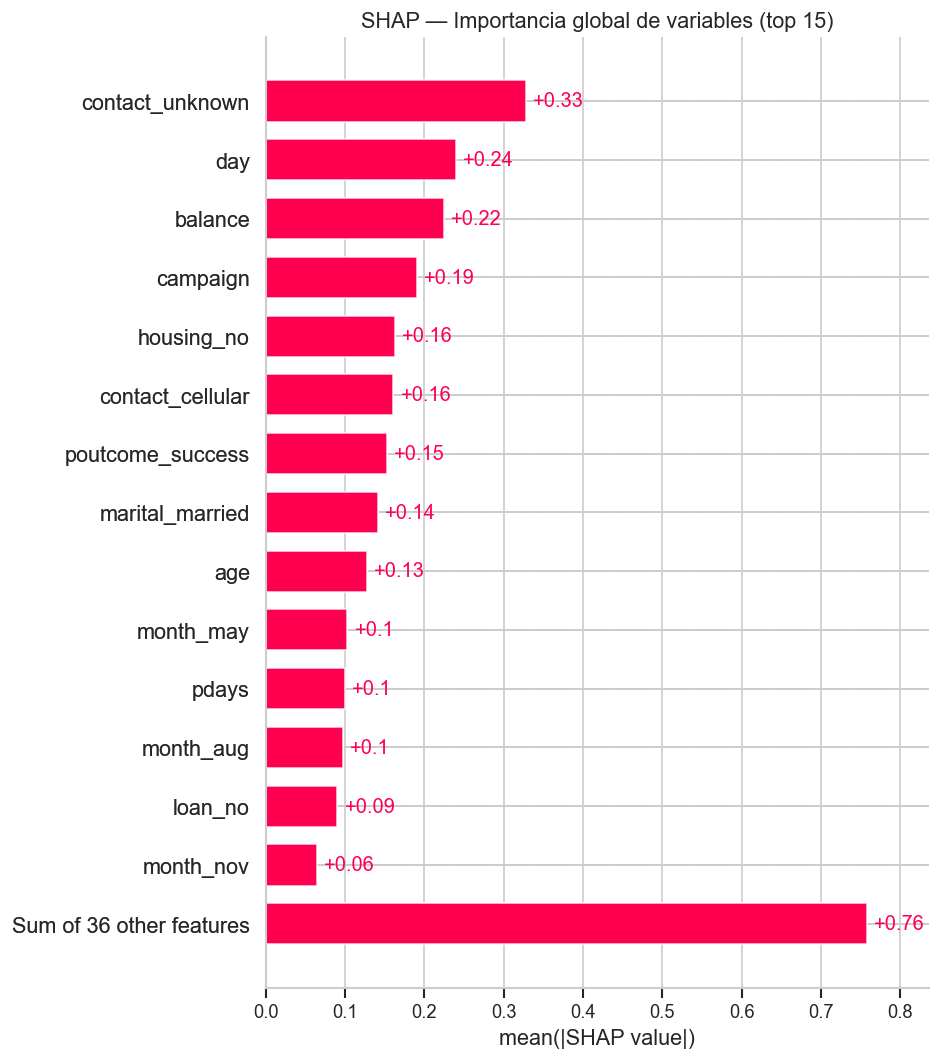

In [17]:
# SHAP Global: importancia promedio

plt.figure(figsize=(10, 7))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("SHAP — Importancia global de variables (top 15)", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/fig_e3_03_shap_bar.png", bbox_inches="tight")
plt.show()

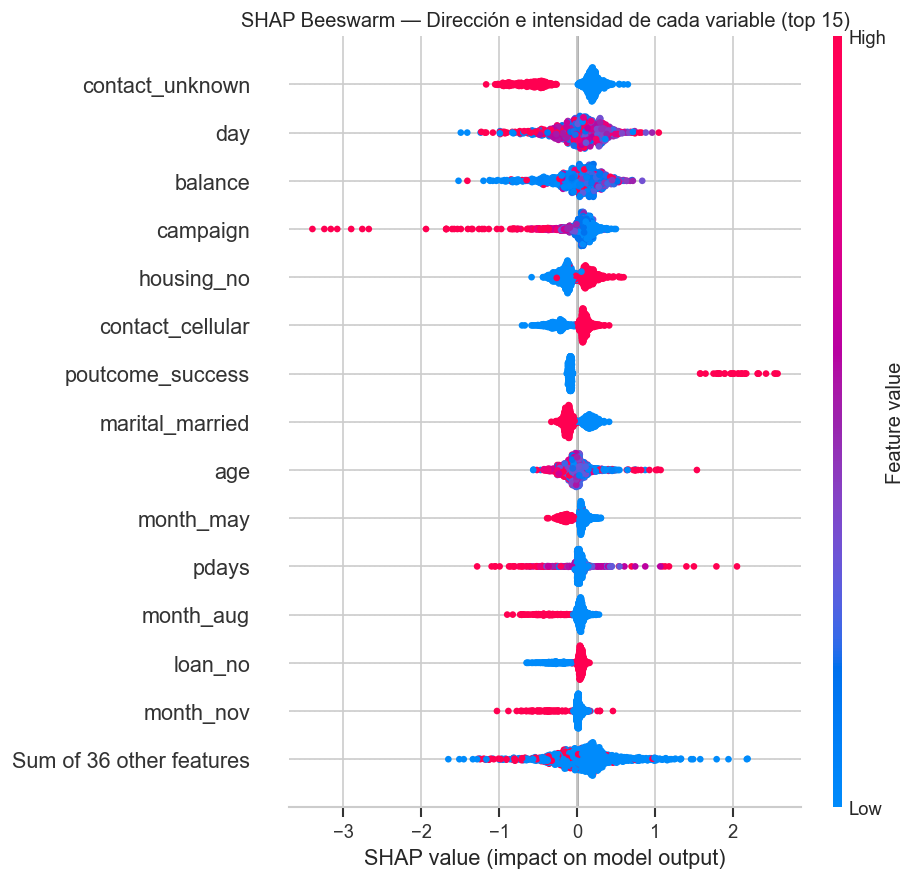

Lectura del gráfico:
 Rojo  = valor alto de la variable
 Azul  = valor bajo de la variable
 Eje X = contribución SHAP (+ empuja hacia 'yes', - empuja hacia 'no')


In [18]:
# SHAP Beeswarm: dirección e intensidad del efecto

plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("SHAP Beeswarm — Dirección e intensidad de cada variable (top 15)",
          fontsize=12)
plt.tight_layout()
plt.savefig("../figures/fig_e3_04_shap_beeswarm.png", bbox_inches="tight")
plt.show()

print("Lectura del gráfico:")
print(" Rojo  = valor alto de la variable")
print(" Azul  = valor bajo de la variable")
print(" Eje X = contribución SHAP (+ empuja hacia 'yes', - empuja hacia 'no')")

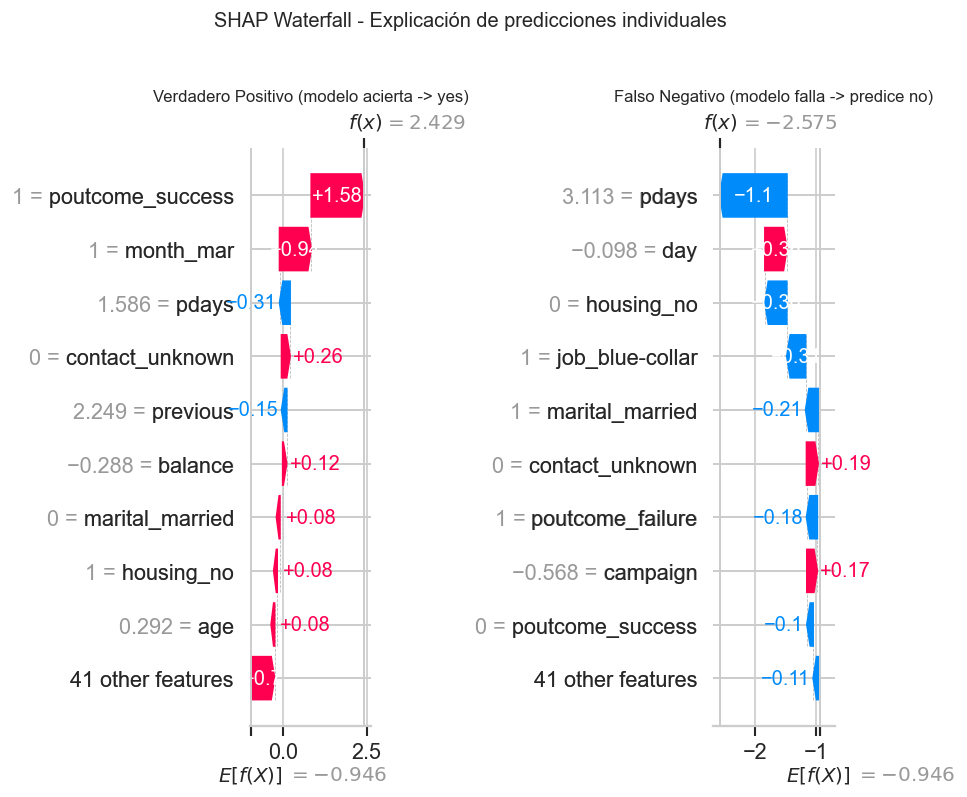

In [19]:
# SHAP Waterfall: explicación de una predicción individual

y_test_arr  = y_test.values
y_pred_arr  = y_pred_test
idx_shap_global = idx_shap

# Encontrar un Verdadero Positivo dentro de la muestra SHAP
y_test_shap = y_test_arr[idx_shap_global]
y_pred_shap = (pipeline_final.predict_proba(X_test.iloc[idx_shap_global])[:, 1]
               >= UMBRAL_OPTIMO).astype(int)

tp_mask = (y_test_shap == 1) & (y_pred_shap == 1)
fn_mask = (y_test_shap == 1) & (y_pred_shap == 0)

idx_tp = np.where(tp_mask)[0][0] if tp_mask.any() else 0
idx_fn = np.where(fn_mask)[0][0] if fn_mask.any() else 1

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, idx_obs, titulo in [
    (axes[0], idx_tp, "Verdadero Positivo (modelo acierta -> yes)"),
    (axes[1], idx_fn, "Falso Negativo (modelo falla -> predice no)"),
]:
    plt.sca(ax)
    shap.plots.waterfall(shap_values[idx_obs], max_display=10, show=False)
    ax.set_title(titulo, fontsize=10)

plt.suptitle("SHAP Waterfall - Explicación de predicciones individuales",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("../figures/fig_e3_05_shap_waterfall.png", bbox_inches="tight")
plt.show()

<Figure size 1080x600 with 0 Axes>

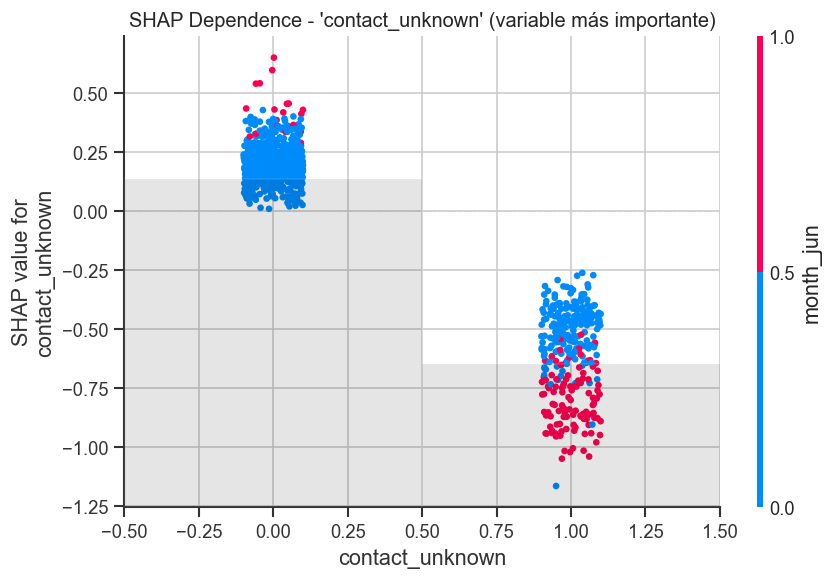

In [20]:
# Dependence: relación entre una variable y su impacto

# Variable más importante según SHAP
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top_var_idx   = np.argmax(mean_abs_shap)
top_var_name  = col_names[top_var_idx]

plt.figure(figsize=(9, 5))
shap.plots.scatter(
    shap_values[:, top_var_name],
    color=shap_values,
    show=False
)
plt.title(f"SHAP Dependence - '{top_var_name}' (variable más importante)",
          fontsize=12)
plt.tight_layout()
plt.savefig("../figures/fig_e3_06_shap_dependence.png", bbox_inches="tight")
plt.show()

---
## 5. Análisis de sensibilidad

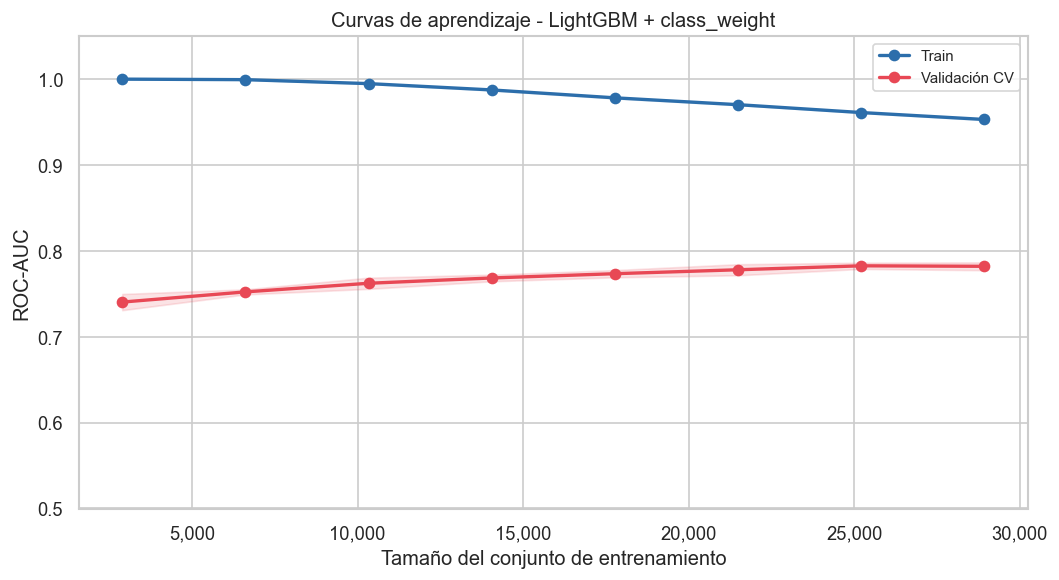

ROC-AUC con 100% de train: 0.7820 ± 0.0046
ROC-AUC con  10% de train: 0.7404 ± 0.0094


In [21]:
# Curvas de aprendizaje

train_sizes, train_scores, val_scores = learning_curve(
    pipeline_final,
    X_train, y_train,
    cv           = CV,
    scoring      = "roc_auc",
    train_sizes  = np.linspace(0.10, 1.0, 8),
    n_jobs       = -1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_mean, "o-", color=PALETTE[0], label="Train", linewidth=2)
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color=PALETTE[0])
ax.plot(train_sizes, val_mean, "o-", color=PALETTE[1], label="Validación CV", linewidth=2)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color=PALETTE[1])
ax.set_xlabel("Tamaño del conjunto de entrenamiento")
ax.set_ylabel("ROC-AUC")
ax.set_title("Curvas de aprendizaje - LightGBM + class_weight", fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(0.5, 1.05)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("../figures/fig_e3_07_learning_curves.png", bbox_inches="tight")
plt.show()

print(f"ROC-AUC con 100% de train: {val_mean[-1]:.4f} ± {val_std[-1]:.4f}")
print(f"ROC-AUC con  10% de train: {val_mean[0]:.4f} ± {val_std[0]:.4f}")

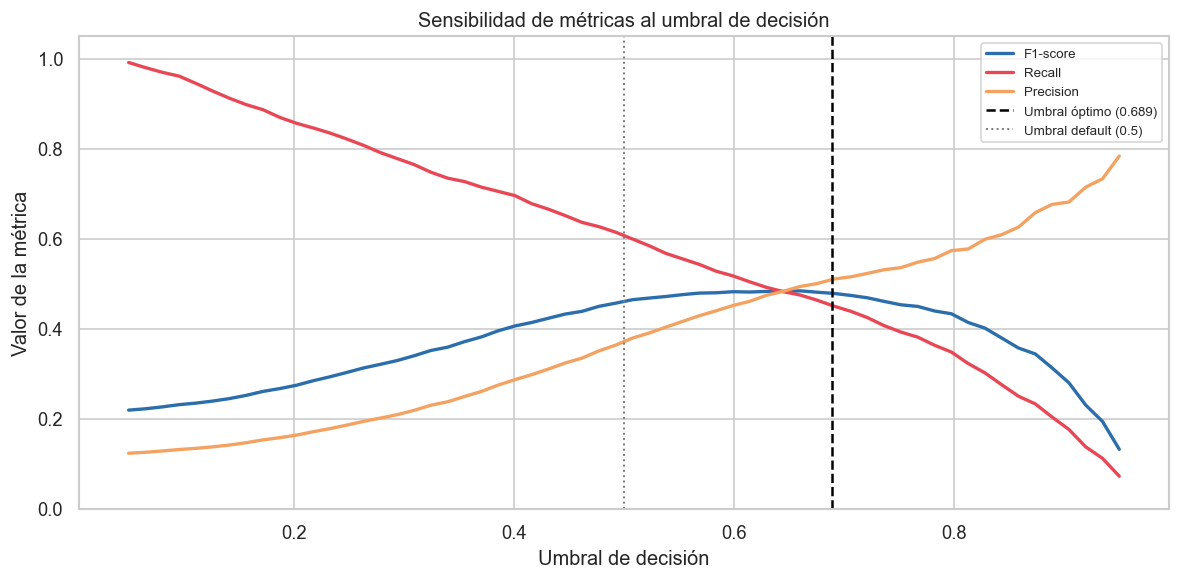

In [22]:
# Estabilidad del umbral

umbrales = np.linspace(0.05, 0.95, 60)
f1s, recalls, precisions = [], [], []

for u in umbrales:
    preds = (y_proba_test >= u).astype(int)
    f1s.append(f1_score(y_test, preds, zero_division=0))
    recalls.append(recall_score(y_test, preds, zero_division=0))
    precisions.append(precision_score(y_test, preds, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(umbrales, f1s,         color=PALETTE[0], linewidth=2, label="F1-score")
ax.plot(umbrales, recalls,     color=PALETTE[1], linewidth=2, label="Recall")
ax.plot(umbrales, precisions,  color=PALETTE[2], linewidth=2, label="Precision")
ax.axvline(UMBRAL_OPTIMO, color="black", linestyle="--", linewidth=1.5,
           label=f"Umbral óptimo ({UMBRAL_OPTIMO:.3f})")
ax.axvline(0.5, color="gray", linestyle=":", linewidth=1.2, label="Umbral default (0.5)")
ax.set_xlabel("Umbral de decisión")
ax.set_ylabel("Valor de la métrica")
ax.set_title("Sensibilidad de métricas al umbral de decisión", fontsize=12)
ax.legend(fontsize=8)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("../figures/fig_e3_08_threshold_sensitivity.png", bbox_inches="tight")
plt.show()

---
## 6. Análisis de errores profundo

In [23]:
# Construcción del dataframe de errores

df_test = X_test.copy().reset_index(drop=True)
df_test["y_real"]  = y_test.values
df_test["y_pred"]  = y_pred_test
df_test["y_proba"] = y_proba_test

df_test["tipo"] = "TN"
df_test.loc[(df_test["y_real"]==1) & (df_test["y_pred"]==1), "tipo"] = "TP"
df_test.loc[(df_test["y_real"]==0) & (df_test["y_pred"]==1), "tipo"] = "FP"
df_test.loc[(df_test["y_real"]==1) & (df_test["y_pred"]==0), "tipo"] = "FN"

conteos = df_test["tipo"].value_counts()
print("-- Distribución por tipo de predicción ----------")
for tipo in ["TP", "TN", "FP", "FN"]:
    n   = conteos.get(tipo, 0)
    pct = n / len(df_test) * 100
    print(f"  {tipo}: {n:5,}  ({pct:.1f}%)")

-- Distribución por tipo de predicción ----------
  TP:   477  (5.3%)
  TN: 7,527  (83.2%)
  FP:   458  (5.1%)
  FN:   581  (6.4%)


In [24]:
# Perfil numérico de FN vs TP

vars_num_analisis = ["age", "balance", "campaign", "pdays", "previous"]

perfil = df_test[df_test["tipo"].isin(["TP", "FN"])].groupby("tipo")[vars_num_analisis].mean()
perfil.loc["Diferencia (FN-TP)"] = perfil.loc["FN"] - perfil.loc["TP"]

print("-- Perfil numérico: FN vs TP --------------------------------")
print(perfil.round(2).to_string())

-- Perfil numérico: FN vs TP --------------------------------
                      age  balance  campaign   pdays  previous
tipo                                                          
FN                  40.67  1532.70      2.41   45.18      0.62
TP                  43.38  1912.31      1.74  104.75      1.85
Diferencia (FN-TP)  -2.71  -379.62      0.67  -59.56     -1.23


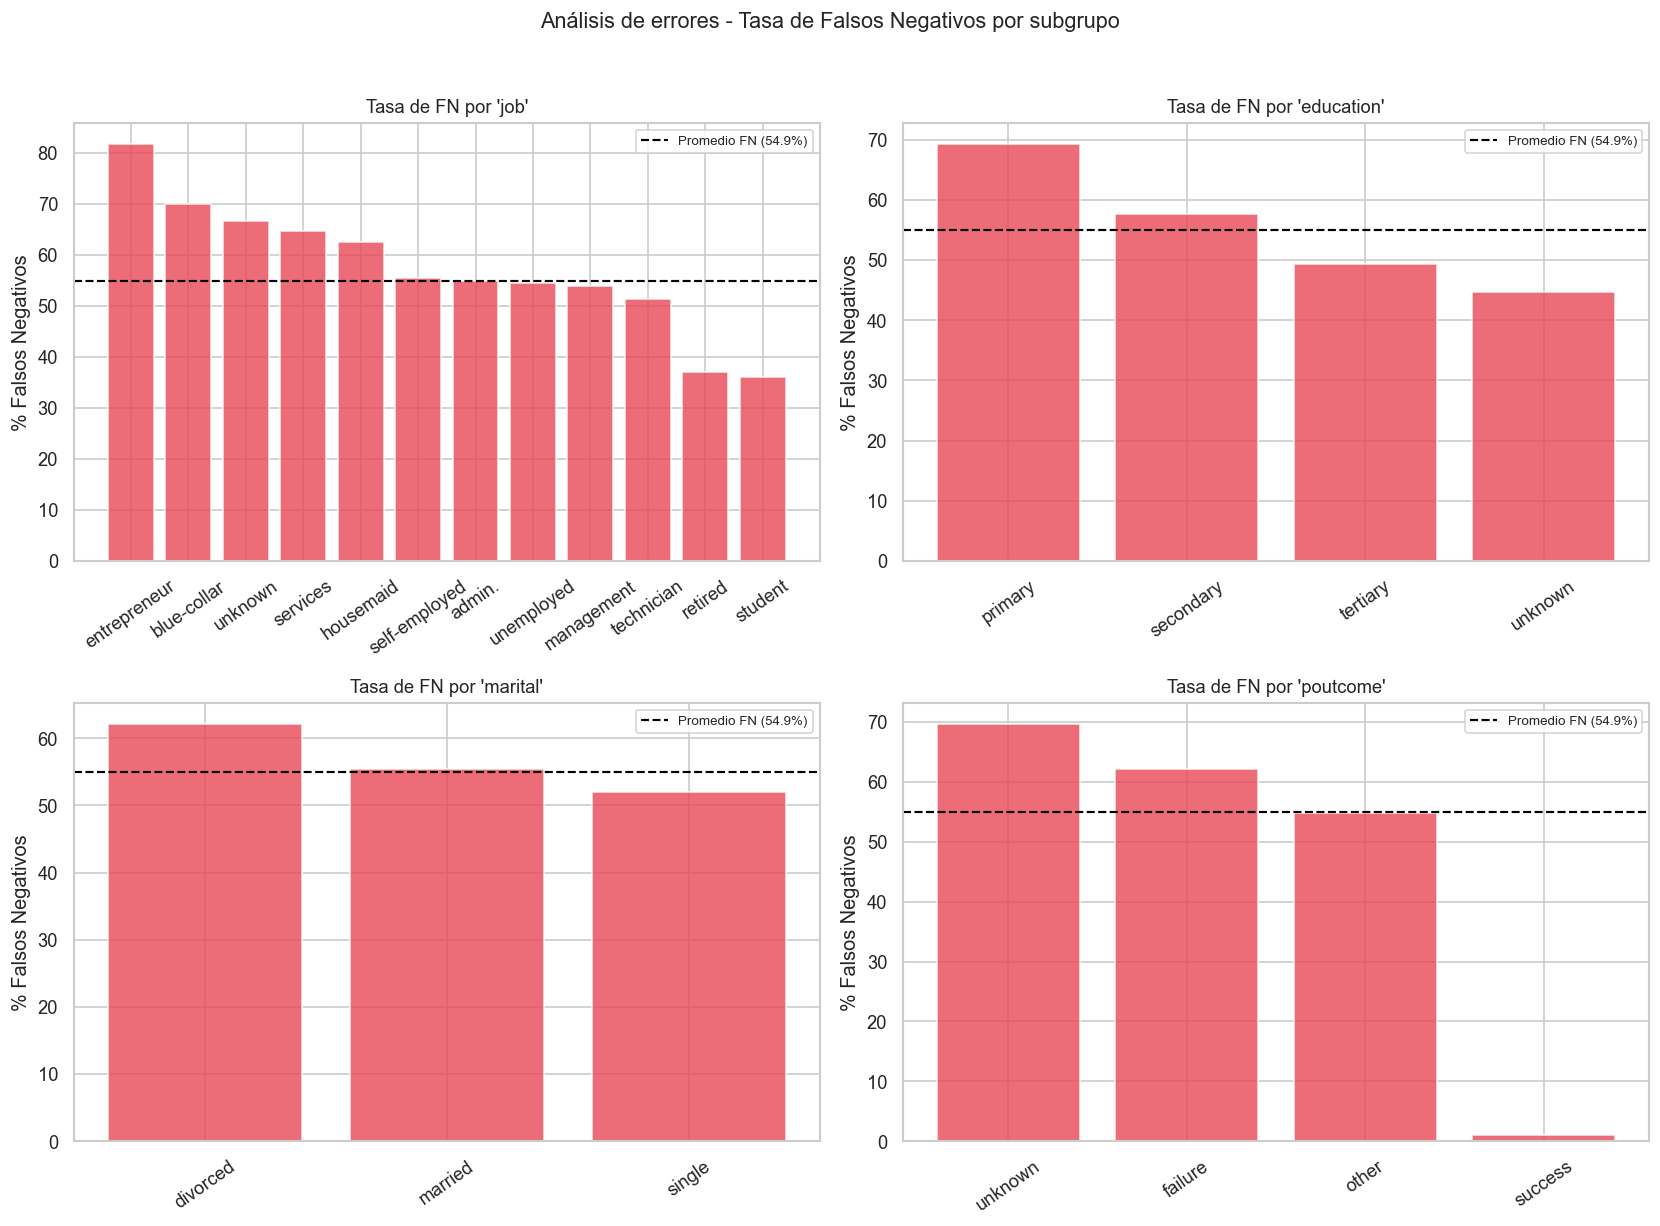

In [25]:
# Perfil categórico: tasa de error por subgrupo

vars_cat_analisis = ["job", "education", "marital", "poutcome"]

# Solo sobre los casos positivos reales
df_positivos = df_test[df_test["y_real"] == 1].copy()
df_positivos["es_fn"] = (df_positivos["tipo"] == "FN").astype(int)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(vars_cat_analisis):
    tasa_fn = (
        df_positivos.groupby(col)["es_fn"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    tasa_fn.columns = [col, "tasa_fn"]
    tasa_fn["tasa_fn"] = tasa_fn["tasa_fn"] * 100

    promedio_fn = df_positivos["es_fn"].mean() * 100

    bars = axes[i].bar(tasa_fn[col], tasa_fn["tasa_fn"],
                       color=PALETTE[1], alpha=0.8, edgecolor="white")
    axes[i].axhline(promedio_fn, color="black", linestyle="--", linewidth=1.3,
                    label=f"Promedio FN ({promedio_fn:.1f}%)")
    axes[i].set_title(f"Tasa de FN por '{col}'", fontsize=11)
    axes[i].set_ylabel("% Falsos Negativos")
    axes[i].tick_params(axis="x", rotation=35)
    axes[i].legend(fontsize=8)

plt.suptitle("Análisis de errores - Tasa de Falsos Negativos por subgrupo",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../figures/fig_e3_09_perfil_fn.png", bbox_inches="tight")
plt.show()

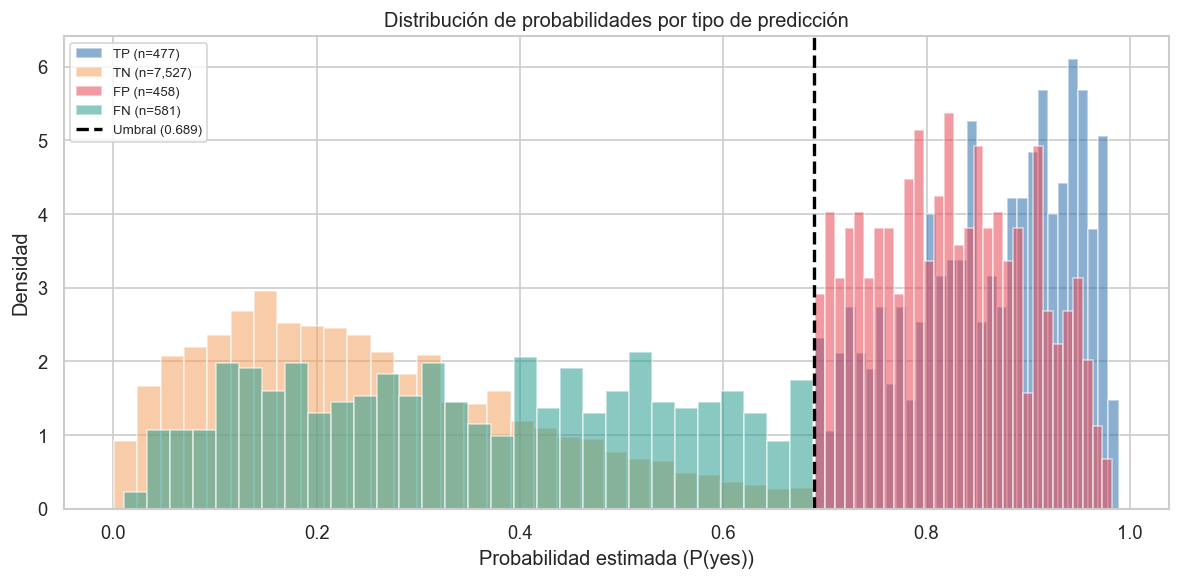

In [27]:
# Distribución de probabilidades por tipo de predicción

fig, ax = plt.subplots(figsize=(10, 5))
colores_tipo = {"TP": PALETTE[0], "TN": PALETTE[2], "FP": PALETTE[1], "FN": PALETTE[3]}

for tipo, color in colores_tipo.items():
    subset = df_test[df_test["tipo"] == tipo]["y_proba"]
    ax.hist(subset, bins=30, alpha=0.55, color=color,
            label=f"{tipo} (n={len(subset):,})", density=True)

ax.axvline(UMBRAL_OPTIMO, color="black", linestyle="--", linewidth=2,
           label=f"Umbral ({UMBRAL_OPTIMO:.3f})")
ax.set_xlabel("Probabilidad estimada (P(yes))")
ax.set_ylabel("Densidad")
ax.set_title("Distribución de probabilidades por tipo de predicción", fontsize=12)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../figures/fig_e3_10_prob_dist_tipos.png", bbox_inches="tight")
plt.show()

---
## 7. Registro de decisiones metodológicas

In [28]:
# ── Tabla de decisiones metodológicas ────────────────────────────────────────

decisiones = pd.DataFrame([
    {
        "Decisión"       : "Exclusión de 'duration'",
        "Qué se hizo"    : "Variable eliminada desde la separación de conjuntos",
        "Justificación"  : "Solo se conoce después de la llamada; su inclusión infla artificialmente las métricas (data leakage)",
        "Evidencia"      : "Capa 2 Entrega 2: +0.05-0.10 ROC-AUC con vs sin duration"
    },
    {
        "Decisión"       : "División 80/20 estratificada",
        "Qué se hizo"    : "train_test_split con stratify=y y random_state=42",
        "Justificación"  : "Preserva la proporción 88/12 en ambos conjuntos; la semilla garantiza reproducibilidad",
        "Evidencia"      : "Entrega 1: proporciones idénticas en train y test"
    },
    {
        "Decisión"       : "Validación cruzada 5-fold estratificada",
        "Qué se hizo"    : "StratifiedKFold(n_splits=5) sobre X_train",
        "Justificación"  : "Estima el desempeño generalizable sin usar test; 5 pliegues balancea sesgo-varianza para ~36K muestras",
        "Evidencia"      : "Std entre pliegues < 0.01 → resultados estables"
    },
    {
        "Decisión"       : "Selección de LightGBM",
        "Qué se hizo"    : "Comparación de 3 familias en 5-fold CV (Entrega 2)",
        "Justificación"  : "Mayor ROC-AUC y F1 en CV; manejo nativo de desbalance; más eficiente que RF en tiempo de entrenamiento",
        "Evidencia"      : "Capa 1 Entrega 2: LightGBM > RF > LR en ROC-AUC"
    },
    {
        "Decisión"       : "class_weight como técnica de desbalance",
        "Qué se hizo"    : "is_unbalance=True en LightGBM (equivalente a class_weight='balanced')",
        "Justificación"  : "Mayor F1 en CV entre las 9 configuraciones (0.4535 vs 0.3822 de SMOTE); más simple y sin riesgo de leakage por oversampling",
        "Evidencia"      : "Capa 3 Entrega 2: LightGBM + class_weight F1=0.4535 > LightGBM + SMOTE F1=0.3822"
    },
    {
        "Decisión"       : "Umbral óptimo en lugar de 0.5",
        "Qué se hizo"    : "Umbral calculado sobre validación interna maximizando F1 en curva PR",
        "Justificación"  : "Con desbalance 88/12, el umbral default favorece la clase mayoritaria; bajar el umbral mejora la detección de 'yes'",
        "Evidencia"      : "Entrega 2 Sección 6: F1 mejora con umbral óptimo vs 0.5"
    },
    {
        "Decisión"       : "ROC-AUC como métrica principal",
        "Qué se hizo"    : "ROC-AUC para comparar modelos; F1 como métrica complementaria",
        "Justificación"  : "ROC-AUC es independiente del umbral y robusta al desbalance; F1 mide desempeño en clase minoritaria",
        "Evidencia"      : "Accuracy=0.88 con DummyClassifier demuestra que no es métrica válida aquí"
    }
])

print("-- Registro de decisiones metodológicas ---------------------")
for _, fila in decisiones.iterrows():
    print(f"\n  [{fila['Decisión']}]")
    print(f"    Qué : {fila['Qué se hizo']}")
    print(f"    Por : {fila['Justificación']}")
    print(f"    Evid: {fila['Evidencia']}")

-- Registro de decisiones metodológicas ---------------------

  [Exclusión de 'duration']
    Qué : Variable eliminada desde la separación de conjuntos
    Por : Solo se conoce después de la llamada; su inclusión infla artificialmente las métricas (data leakage)
    Evid: Capa 2 Entrega 2: +0.05-0.10 ROC-AUC con vs sin duration

  [División 80/20 estratificada]
    Qué : train_test_split con stratify=y y random_state=42
    Por : Preserva la proporción 88/12 en ambos conjuntos; la semilla garantiza reproducibilidad
    Evid: Entrega 1: proporciones idénticas en train y test

  [Validación cruzada 5-fold estratificada]
    Qué : StratifiedKFold(n_splits=5) sobre X_train
    Por : Estima el desempeño generalizable sin usar test; 5 pliegues balancea sesgo-varianza para ~36K muestras
    Evid: Std entre pliegues < 0.01 → resultados estables

  [Selección de LightGBM]
    Qué : Comparación de 3 familias en 5-fold CV (Entrega 2)
    Por : Mayor ROC-AUC y F1 en CV; manejo nativo de desbalanc

---
## 8. Conclusiones y recomendaciones

In [ ]:
# Tabla resumen final de métricas

resumen = pd.DataFrame({
    "Métrica"            : ["ROC-AUC", "F1-score", "Recall", "Precision", "Accuracy"],
    "5-fold CV (media)"  : [
        cv_results["test_roc_auc"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_accuracy"].mean()
    ],
    "Test (final)"       : [
        metricas_test["ROC-AUC"],
        metricas_test["F1-score"],
        metricas_test["Recall"],
        metricas_test["Precision"],
        metricas_test["Accuracy"]
    ]
})

print("-- TABLA RESUMEN FINAL --------------------------------------")
print(resumen.to_string(index=False, float_format="{:.4f}".format))
print()
print("Modelo  : LightGBM + class_weight (is_unbalance=True)")
print(f"Umbral  : {UMBRAL_OPTIMO:.4f}")
print(f"Dataset : Bank Marketing | 45,211 registros | 14 features (sin duration)")

### ¿Cuál es el mejor modelo y por qué?

El mejor modelo es LightGBM con `is_unbalance=True` (class_weight) y umbral de decisión ajustado. La selección se basa en evidencia experimental de tres capas (Entrega 2):

- **Capa 1:** LightGBM supera a Logistic Regression y Random Forest en ROC-AUC en 5-fold CV.
- **Capa 3:** LightGBM + class_weight tiene el mayor F1 entre las 9 configuraciones (0.4535), superando a LightGBM + SMOTE (0.3822) con una diferencia de 0.071 en F1.
- **Evaluación final:** ROC-AUC = 0.796 sobre test independiente.

---

### ¿Qué tan confiables son sus resultados?

Los resultados son reproducibles y metodológicamente sólidos, con una limitación importante que debe reconocerse:

**Fortalezas:**
- Desviación estándar entre pliegues < 0.01 en ROC-AUC → el modelo es estable ante distintas particiones.
- Las métricas de CV y test son coherentes → no hay fuga de información hacia test.
- Todas las decisiones están registradas y son auditables (Sección 7).

**Limitación - objetivo de ROC-AUC no alcanzado:**  
El objetivo de investigación era superar 0.85 de ROC-AUC. El modelo final alcanzó 0.796, quedando 0.054 puntos por debajo. Esto no invalida el proyecto - el modelo supera ampliamente el baseline (0.50) y la Regresión Logística sin ajuste - pero señala trabajo pendiente. 

---

### ¿Qué variables o patrones explican el desempeño?

El análisis SHAP identifica los factores más determinantes:

| Variable | Efecto sobre la predicción |
|---|---|
|  | Mayor impacto positivo: campaña previa exitosa aumenta fuertemente la probabilidad de aceptar |
|  | Meses de marzo, septiembre y diciembre tienen tasas superiores al promedio |
|  | Balance bancario alto correlaciona positivamente con aceptación |
|  | Más contactos en la campaña actual reduce la probabilidad (fatiga del cliente) |
|  /  | Haber sido contactado previamente y con buen resultado aumenta la probabilidad |

El patrón central: El historial de interacción previa es el predictor más fuerte. Un cliente que ya respondió bien a una campaña anterior es el mejor candidato para la siguiente.

---

### ¿Qué conclusiones útiles deja el proyecto?

1. **La segmentación supera al volumen de contactos.** Campaña alta (muchos contactos) reduce la tasa de conversión. Contactar menos pero a los clientes correctos es más eficiente.

2. **El historial es el mejor predictor disponible.** Clientes con  tienen tasas de aceptación muy superiores al promedio. Una estrategia de recontacto informado puede ser significativamente más rentable que campañas masivas.

3. **El data leakage es un riesgo real y cuantificable.** Incluir  infla el ROC-AUC entre 0.05 y 0.10 puntos (evidenciado en Capa 2). En producción, esto llevaría a desplegar un modelo con desempeño irreal.

4. **La accuracy es una métrica engañosa con desbalance.** El DummyClassifier obtiene 88% de accuracy sin aprender nada. ROC-AUC y F1 son las métricas apropiadas para este problema.

5. **El objetivo cuantitativo planteado (ROC-AUC > 0.85) no se alcanzó** con el conjunto de features disponibles sin  y sin búsqueda de hiperparámetros. Esto es una conclusión honesta y técnicamente útil — establece el límite del enfoque actual.

---

### ¿Qué haría falta para mejorar o desplegar la solución?

**Para cerrar la brecha hacia ROC-AUC > 0.85:**
- Búsqueda de hiperparámetros con Optuna o GridSearchCV (n_estimators, max_depth, learning_rate, num_leaves).
- Feature engineering:  desde , interacciones entre  y , variables de ratio como .
- Calibración de probabilidades con para mejorar la calidad de los scores.

**Para desplegar la solución:**
- Serialización del pipeline con  o  para trazabilidad de versiones.
- Monitoreo de distribución de features en producción (*data drift*): si el perfil de clientes cambia, las métricas se degradarán.
- Validación temporal estricta: este dataset es de 2008-2013; revalidar con datos más recientes antes de desplegar.
- Análisis de costo-beneficio: estimar el valor económico de un FN (oportunidad perdida) vs FP (llamada innecesaria) para ajustar el umbral con criterio financiero real, no solo maximizando F1.
- Revisión de equidad (*fairness*): verificar que el modelo no discrimine sistemáticamente por ,  o .
